In [23]:
import re
from collections import defaultdict
from pathlib import Path
import subprocess, tempfile, shutil
import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import font_manager as fm
from scipy.stats import gaussian_kde


In [24]:
BASE    = Path("/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/workspace")
SANDERS = Path("/hpcfs/users/a1864358/sanders_lab")
RESULTS = BASE / "res"
OUT     = RESULTS / "data"
OUT.mkdir(parents=True, exist_ok=True)

CHROMS = ["ch2", "chZ"]
TILE   = 10_000  # 10 kb bins

# Hydrophis species for cross-species overlays
SPECIES = ["horn", "hmaj", "hcy", "hcurw", "hcure"]
SP_LAB  = {
    "horn":  "H. ornatus",
    "hmaj":  "H. major",
    "hcy":   "H. cyanocinctus",
    "hcurw": "H. curtus (W)",
    "hcure": "H. curtus (E)",
}
SP_PAL = {
    "horn":  "#1f4e8c",
    "hmaj":  "#2a9d8f",
    "hcy":   "#e9c46a",
    "hcurw": "#e76f51",
    "hcure": "#9b2226",
}

ASM    = SANDERS / "resources/final-asms"
EDTA   = SANDERS / "asm/files/repeat-anno"
V2RDIR = SANDERS / "asm/files/annotation/eviann_results/hmaj/curation/results"


def species_paths(sp: str) -> dict:
    """Resolve FAI / RM .out / V2R for one species (EDTA .out preferred for class)."""
    fai = ASM / f"10-{sp}-final.renamed.fa.fai"
    rm_out = EDTA / f"edta_10-{sp}" / "repeatmasker_out" / f"10-{sp}-final.renamed.fa.out"
    if not rm_out.exists():
        cands = sorted((EDTA / f"edta_10-{sp}").glob("*.out"))
        rm_out = cands[0] if cands else rm_out
    v2r = V2RDIR / sp / "v2r_genes.tsv"
    return {"fai": fai, "rm_out": rm_out, "v2r": v2r,
            "bins": OUT / f"{sp}_ltr_line_density_distance_10kb_bins.tsv"}


BINS_ALL = OUT / "hydrophis_ltr_line_density_distance_10kb_bins.tsv"

try:
    fpath = str(BASE.parent / "inv/tech-rep/assets/fonts/EBGaramond.ttf")
    fm.fontManager.addfont(fpath)
    FONT = fm.FontProperties(fname=fpath).get_name()
    mpl.rcParams.update({"font.family": "serif", "font.serif": [FONT, "DejaVu Serif"]})
except Exception:
    pass

mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.9,
})

BLUE = "#1f4e8c"
RED  = "#b32020"
GREY = "#7a7a7a"
PAL  = {"ch2": BLUE, "chZ": RED}
LAB  = {"ch2": "C2", "chZ": "CZ"}


def sigstar(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


for sp in SPECIES:
    p = species_paths(sp)
    missing = [k for k, v in p.items() if k != "bins" and not Path(v).exists()]
    print(f"{sp:6}  {'OK' if not missing else 'MISSING ' + ','.join(missing)}")
    if not missing:
        print(f"         out={p['rm_out'].name}")


horn    OK
         out=10-horn-final.renamed.fa.out
hmaj    OK
         out=10-hmaj-final.renamed.fa.out
hcy     OK
         out=10-hcy-final.renamed.fa.out
hcurw   OK
         out=10-hcurw-final.renamed.fa.out
hcure   OK
         out=10-hcure-final.renamed.fa.out


## Cross-species inputs
- Chromosomes analysed: **ch2** + **chZ**. Outputs: one 10 kb bin table per species


In [25]:
def _overlap_widths(bin_s, bin_e, iv_s, iv_e):
    """Inclusive overlap lengths; negative ⇒ no overlap."""
    return np.minimum(bin_e, iv_e) - np.maximum(bin_s, iv_s) + 1


def overlap_sum_widths(bin_s, bin_e, iv_s, iv_e):
    """Sum inclusive overlap widths (overlaps counted separately → density can exceed 1)."""
    w = _overlap_widths(bin_s, bin_e, iv_s, iv_e)
    return float(w[w > 0].sum())


def dist_to_nearest(bin_s, bin_e, feat_s, feat_e):
    """0 if overlap, else bp gap to nearest feature (start2 - end1 - 1)."""
    if len(feat_s) == 0:
        return np.nan
    gap = np.maximum(feat_s - bin_e - 1, bin_s - feat_e - 1)
    return int(np.where(gap < 0, 0, gap).min())


def bin_index_map(starts, ends, tile):
    idx = defaultdict(list)
    for i, (s, e) in enumerate(zip(starts.tolist(), ends.tolist())):
        for bi in range((s - 1) // tile, (e - 1) // tile + 1):
            idx[bi].append(i)
    return {k: np.asarray(v, dtype=int) for k, v in idx.items()}


def tile_genome(fai_path, chroms=CHROMS, tile=TILE):
    fai = pd.read_csv(fai_path, sep="\t", header=None, names=["chr", "length", "o", "b", "bl"])
    genome = {r.chr: int(r.length) for r in fai.itertuples() if r.chr in chroms}
    rows = []
    for c in chroms:
        L, start = genome[c], 1
        while start <= L:
            end = min(start + tile - 1, L)
            rows.append((c, start, end, end - start + 1))
            start = end + 1
    return pd.DataFrame(rows, columns=["chr", "start", "end", "width"])


def load_v2r_intact(v2r_path, chroms=CHROMS):
    """Intact curation loci, deduped by locus_id."""
    df = pd.read_csv(v2r_path, sep="\t")
    df = df.loc[df["coverage_class"].astype(str).str.lower() == "intact"].copy()
    df = df.drop_duplicates("locus_id")
    df = df.loc[df["chrom"].isin(chroms), ["chrom", "locus_start", "locus_end"]].copy()
    df = df.rename(columns={"chrom": "chr", "locus_start": "start", "locus_end": "end"})
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)
    return df.reset_index(drop=True)


def load_rm_out(rm_path, chroms=CHROMS):
    """Parse RepeatMasker .out → (chr, start, end, class). Coords are 1-based inclusive."""
    rows = []
    with open(rm_path) as fh:
        for i, ln in enumerate(fh):
            if i < 3:
                continue
            p = ln.split()
            if len(p) < 11:
                continue
            chrom = p[4]
            if chrom not in chroms:
                continue
            try:
                s, e = int(p[5]), int(p[6])
            except ValueError:
                continue
            if e < s:
                s, e = e, s
            rows.append((chrom, s, e, p[10]))
    return pd.DataFrame(rows, columns=["chr", "start", "end", "te_class"])

def load_ltr_intervals(sp, chroms=CHROMS):
    """LTR intervals (1-based inclusive) from EDTA/RM .out for one species."""
    rep = load_rm_out(species_paths(sp)["rm_out"], chroms=chroms)
    return (rep.loc[rep["te_class"].astype(str).str.startswith("LTR/"), ["chr", "start", "end"]]
            .reset_index(drop=True))


def build_species_bins(sp: str) -> pd.DataFrame:
    """10 kb bins with ltr_density, line_density, dist_to_v2r for one species."""
    paths = species_paths(sp)
    bins = tile_genome(paths["fai"])
    v2r = load_v2r_intact(paths["v2r"])
    rep = load_rm_out(paths["rm_out"])
    ltr = rep.loc[rep["te_class"].astype(str).str.startswith("LTR/")].copy()
    # class may be "LINE/…" or bare "LINE"
    line = rep.loc[rep["te_class"].astype(str).str.startswith("LINE")].copy()
    print(f"{sp}: bins={len(bins)}  V2R_intact={len(v2r)}  LTR={len(ltr)}  LINE={len(line)}")

    parts = []
    for chrom in CHROMS:
        b = bins.loc[bins.chr == chrom].reset_index(drop=True)
        bs, be = b.start.to_numpy(), b.end.to_numpy()
        v = v2r.loc[v2r.chr == chrom]
        vs, ve = v.start.to_numpy(), v.end.to_numpy()
        v_idx = bin_index_map(vs, ve, TILE) if len(vs) else {}

        out = b.copy()
        for label, sub in (("ltr_density", ltr), ("line_density", line)):
            r = sub.loc[sub.chr == chrom]
            rs, re_ = r.start.to_numpy(), r.end.to_numpy()
            r_idx = bin_index_map(rs, re_, TILE) if len(rs) else {}
            dens = np.zeros(len(b), dtype=float)
            for i, (s, e) in enumerate(zip(bs, be)):
                hit = r_idx.get((s - 1) // TILE)
                if hit is None:
                    continue
                dens[i] = overlap_sum_widths(s, e, rs[hit], re_[hit]) / b.width.iloc[i]
            out[label] = dens

        dist = np.full(len(b), np.nan)
        for i, (s, e) in enumerate(zip(bs, be)):
            # nearest can be outside the local tile window — search all V2R on chrom
            dist[i] = dist_to_nearest(s, e, vs, ve)
        out["dist_to_v2r"] = dist
        out["species"] = sp
        parts.append(out)

    df = pd.concat(parts, ignore_index=True)
    df.to_csv(paths["bins"], sep="\t", index=False)
    return df


# build all species
all_parts = [build_species_bins(sp) for sp in SPECIES]
bins_all = pd.concat(all_parts, ignore_index=True)
bins_all.to_csv(BINS_ALL, sep="\t", index=False)
print("wrote", BINS_ALL, "nrows", len(bins_all))
bins_all.groupby("species")[["ltr_density", "line_density"]].mean()


horn: bins=58439  V2R_intact=174  LTR=409579  LINE=36497
hmaj: bins=56711  V2R_intact=188  LTR=394861  LINE=47343
hcy: bins=54811  V2R_intact=146  LTR=382474  LINE=29738
hcurw: bins=59036  V2R_intact=167  LTR=410265  LINE=48761
hcure: bins=49053  V2R_intact=87  LTR=334111  LINE=18692
wrote /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/workspace/res/data/hydrophis_ltr_line_density_distance_10kb_bins.tsv nrows 278050


,ltr_density,line_density
species,,
hcure,0.367765,0.010306
hcurw,0.385097,0.027713
hcy,0.372613,0.015662
hmaj,0.371640,0.023697
horn,0.377725,0.019312


---

# LTRs — all Hydrophis

#### Distance-decay spatial profile

Mean LTR density per 10 kb bin vs distance to the nearest **intact** V2R locus.
- Solid = ch2, dashed = chZ
- Shaded band = 95% CI of the mean
- Repeats from EDTA/RepeatMasker `.out` (class `LTR/*`)

##### Results:
- Repeat density is highest flanking adjacent V2R loci @ ~= 10-50kb, -> then declines sharpely 
- This pattern = consistent on CZ & C2 at all distances


wrote /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/workspace/res/hydrophis_ltr_density_distance_decay.png


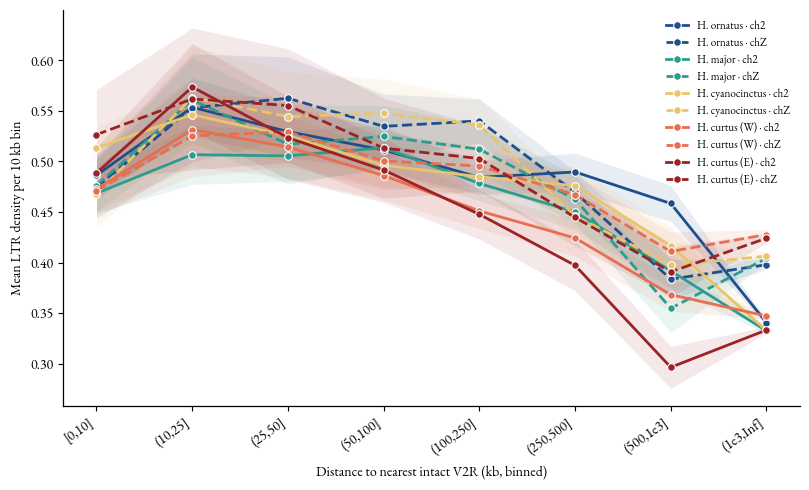

In [26]:
DIST_EDGES  = [0, 10, 25, 50, 100, 250, 500, 1000, np.inf]
DIST_LABELS = ["[0,10]", "(10,25]", "(25,50]", "(50,100]",
               "(100,250]", "(250,500]", "(500,1e3]", "(1e3,Inf]"]


def plot_species_density_decay(density_col, ylabel, title):
    """Overlay all Hydrophis species; chrom encoded by linestyle."""
    df = pd.read_csv(BINS_ALL, sep="\t")
    df["dist_kb"] = df["dist_to_v2r"] / 1000.0
    df["dbin"] = pd.cut(df["dist_kb"], bins=DIST_EDGES, labels=DIST_LABELS,
                        include_lowest=True)
    df = df.dropna(subset=["dbin", density_col])

    g = (df.groupby(["species", "chr", "dbin"], observed=True)[density_col]
           .agg(["mean", "sem"]).reset_index())
    g["lo"] = g["mean"] - 1.96 * g["sem"]
    g["hi"] = g["mean"] + 1.96 * g["sem"]
    xi = {lab: i for i, lab in enumerate(DIST_LABELS)}
    ls_map = {"ch2": "-", "chZ": "--"}

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ymin, ymax = np.inf, -np.inf
    for sp in SPECIES:
        for ch in CHROMS:
            s = (g[(g.species == sp) & (g.chr == ch)]
                   .set_index("dbin").reindex(DIST_LABELS).reset_index())
            if s["mean"].isna().all():
                continue
            x = list(range(len(DIST_LABELS)))
            ax.fill_between(x, s["lo"], s["hi"], color=SP_PAL[sp], alpha=0.10, lw=0)
            ax.plot(x, s["mean"], color=SP_PAL[sp], lw=2.0, marker="o", ms=5.5,
                    mec="white", mew=0.8, ls=ls_map[ch],
                    label=f"{SP_LAB[sp]} · {ch}")
            ymin = min(ymin, float(np.nanmin(s["lo"])))
            ymax = max(ymax, float(np.nanmax(s["hi"])))

    ax.set_xticks(range(len(DIST_LABELS)))
    ax.set_xticklabels(DIST_LABELS, rotation=35, ha="right")
    ax.set_xlabel("Distance to nearest intact V2R (kb, binned)", labelpad=6)
    ax.set_ylabel(ylabel)
    pad = 0.05 * (ymax - ymin) if np.isfinite(ymax) and ymax > ymin else 0.01
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(title, pad=8)
    ax.legend(frameon=False, loc="upper right", fontsize=8, ncol=1)
    fig.tight_layout()
    out = RESULTS / f"hydrophis_{density_col}_distance_decay.png"
    fig.savefig(out, dpi=200)
    print("wrote", out)
    plt.show()


plot_species_density_decay(
    "ltr_density",
    "Mean LTR density per 10 kb bin",
    "",
)


---

# LINEs — all Hydrophis

#### Distance-decay spatial profile

- Same layout as the LTR plot, using RepeatMasker class `LINE*` (includes `LINE/…` and bare `LINE`).

##### Results:
- no real flanking enrichment/signal


wrote /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/workspace/res/hydrophis_line_density_distance_decay.png


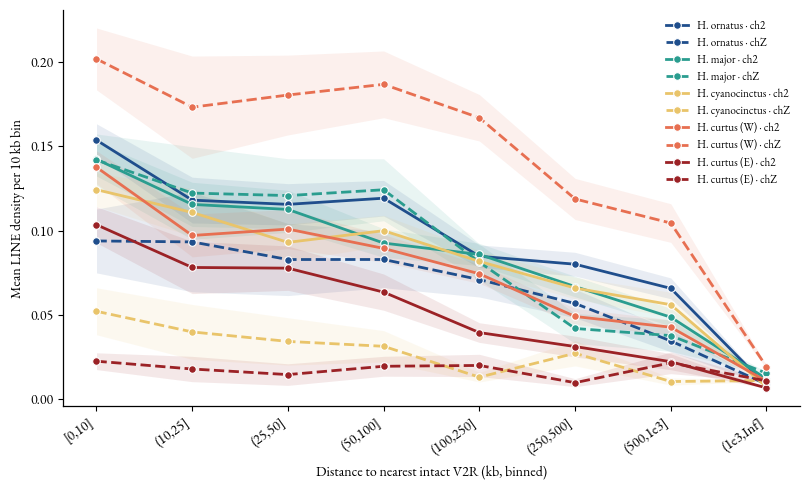

In [27]:
plot_species_density_decay(
    "line_density",
    "Mean LINE density per 10 kb bin",
    "",
)

#### Cluster merge distance & pseudoreplication
- To correct for **pseudoreplication**, adjacent intact loci are merged into clusters using a gap-closure threshold (**39.81 kb** = `MERGE_FOCUS`, chosen between modes of the nearest-V2R gap distribution).
- Nearest-neighbour gap distributions motivate that threshold; cluster-count vs merge-bp shows sensitivity.


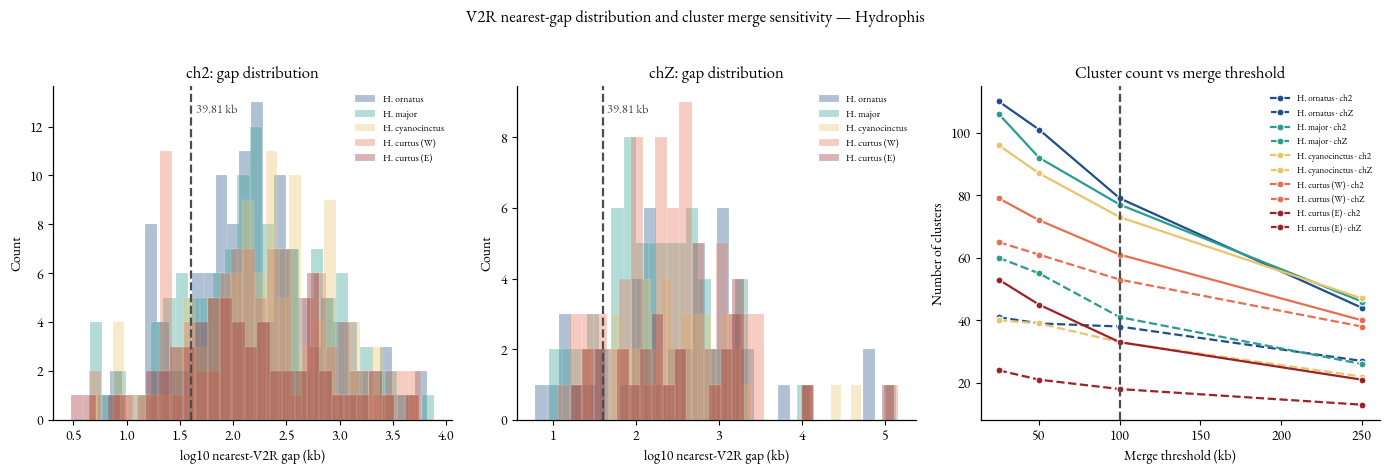

chr      ch2  chZ
species          
hcure     60   25
hcurw     94   71
hcy      104   40
hmaj     121   65
horn     125   47
Empty DataFrame
Columns: []
Index: []


In [35]:
# V2R nearest-gap distribution + cluster merge sensitivity (all Hydrophis) 
MERGE_FOCUS = 39_810  # primary cluster definition for cyclic null (~39.81 kb)
MERGE_THRESHOLDS = sorted({25_000, MERGE_FOCUS, 50_000, 100_000, 250_000})


def nearest_gaps(starts, ends):
    """Sorted loci → nearest-neighbour gaps (bp between consecutive intervals)."""
    if len(starts) < 2:
        return np.array([], dtype=np.int64)
    order = np.argsort(starts, kind="mergesort")
    s, e = starts[order], ends[order]
    return np.maximum(0, s[1:] - e[:-1] - 1).astype(np.int64)


def build_clusters(starts, ends, merge_bp):
    """Merge if start <= end + merge_bp (GenomicRanges reduce min.gapwidth = merge_bp)."""
    if len(starts) == 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64), np.array([], dtype=np.int64)
    order = np.argsort(starts, kind="mergesort")
    s, e = starts[order].astype(np.int64), ends[order].astype(np.int64)
    cs, ce, nloc = [int(s[0])], [int(e[0])], [1]
    for a, b in zip(s[1:], e[1:]):
        if a <= ce[-1] + merge_bp:
            ce[-1] = max(ce[-1], int(b))
            nloc[-1] += 1
        else:
            cs.append(int(a)); ce.append(int(b)); nloc.append(1)
    return np.asarray(cs), np.asarray(ce), np.asarray(nloc, dtype=np.int64)


gap_rows, clus_rows, v2r_by_sp = [], [], {}
for sp in SPECIES:
    p = species_paths(sp)
    v2r = load_v2r_intact(p["v2r"])
    v2r_by_sp[sp] = v2r
    fai = pd.read_csv(p["fai"], sep="\t", header=None, names=["chr", "length", "o", "b", "bl"])
    for ch in CHROMS:
        sub = v2r.loc[v2r.chr == ch]
        s = sub.start.to_numpy(dtype=np.int64)
        e = sub.end.to_numpy(dtype=np.int64)
        for g in nearest_gaps(s, e):
            gap_rows.append({"species": sp, "chr": ch, "gap_bp": int(g)})
        for mb in MERGE_THRESHOLDS:
            cs, ce, nl = build_clusters(s, e, mb)
            for i, (a, b, n) in enumerate(zip(cs, ce, nl), 1):
                clus_rows.append({
                    "species": sp, "merge_bp": mb, "chr": ch,
                    "start": int(a), "end": int(b), "width": int(b - a + 1),
                    "n_loci": int(n), "cluster_id": f"{ch}_{i}",
                })

gaps = pd.DataFrame(gap_rows)
clus = pd.DataFrame(clus_rows)
gaps.to_csv(OUT / "hydrophis_v2r_intact_nearest_gaps.tsv", sep="\t", index=False)
clus.to_csv(OUT / "hydrophis_v2r_cluster_summary.tsv", sep="\t", index=False)
ncl = clus.groupby(["species", "chr", "merge_bp"], as_index=False).size().rename(columns={"size": "n_clusters"})

# Figure: gap hists (ch2 / chZ) + cluster-count sensitivity
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, ch in zip(axes[:2], CHROMS):
    for sp in SPECIES:
        g = gaps.loc[(gaps.species == sp) & (gaps.chr == ch), "gap_bp"].to_numpy() / 1000.0
        if g.size == 0:
            continue
        ax.hist(np.log10(g + 1), bins=28, color=SP_PAL[sp], alpha=0.35,
                edgecolor="white", lw=0.3, label=SP_LAB[sp])
    ax.axvline(np.log10(40), color="0.3", lw=1.6, ls="--")
    ax.text(np.log10(40) + 0.05, ax.get_ylim()[1] * 0.92, "39.81 kb",
            fontsize=9, color="0.3")
    ax.set_xlabel("log10 nearest-V2R gap (kb)")
    ax.set_ylabel("Count")
    ax.set_title(f"{ch}: gap distribution")
    ax.legend(frameon=False, fontsize=7, loc="upper right")

ax = axes[2]
for sp in SPECIES:
    for ch, ls in zip(CHROMS, ("-", "--")):
        s = ncl[(ncl.species == sp) & (ncl.chr == ch)].sort_values("merge_bp")
        ax.plot(s["merge_bp"] / 1000, s["n_clusters"], color=SP_PAL[sp], ls=ls,
                marker="o", ms=5, mec="white", mew=0.8, lw=1.6,
                label=f"{SP_LAB[sp]} · {ch}")
ax.axvline(MERGE_FOCUS / 1000, color="0.3", lw=1.6, ls="--")
ax.text(MERGE_FOCUS / 1000 + 2, ax.get_ylim()[1] * 0.92, "39.81 kb", fontsize=9, color="0.3")
ax.set_xlabel("Merge threshold (kb)")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster count vs merge threshold")
ax.legend(frameon=False, fontsize=6.5, loc="upper right", ncol=1)

fig.suptitle("V2R nearest-gap distribution and cluster merge sensitivity — Hydrophis", y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / "hydrophis_v2r_nearest_gap_clusters.png", dpi=200, bbox_inches="tight")
plt.show()
print(gaps.groupby(["species", "chr"]).size().unstack(fill_value=0))
print(ncl[ncl.merge_bp == MERGE_FOCUS].pivot_table(index="species", columns="chr", values="n_clusters"))


# Cyclic permutation

Generally, enrichment tests move gene/cluster positions while keeping the repeat track fixed.
That ignores spatial structure in the LTR track itself (LTR domains / banding).

**Cyclic permutation** keeps V2R clusters fixed in the test statistic's geometry by
circularly rotating one track by a random offset (equivalently: shift clusters by `−offset`
against a fixed reduced LTR track). This preserves:

- exact LTR sizes and spacings
- large-scale LTR spatial autocorrelation

Only the *phase* between V2R clusters and LTR bands is randomised.

Implemented with the **Rust** binary `final-bt/cyclic_rust` (merge gap = `MERGE_FOCUS` = 39 810 bp; rayon + sorted-LTR binary search).


In [30]:
# Rust cyclic_null (primary)

RUST_BIN = BASE.parent / "final-bt" / "cyclic_rust" / "target" / "release" / "cyclic_null"
NTIMES_CYCLIC = 5000
SEED_CYCLIC = 13


def prepare_rust_datadir(sp, tmp_root):
    """Shim datadir layout expected by cyclic_rust (filenames fixed to horn tech-rep)."""
    d = Path(tmp_root) / sp
    d.mkdir(parents=True, exist_ok=True)
    p = species_paths(sp)
    shutil.copy(p["fai"], d / "horn.fa.fai")
    v2r = v2r_by_sp[sp]
    bed = v2r.assign(start0=v2r.start - 1)[["chr", "start0", "end"]]
    bed.to_csv(d / "phmm_intact_loci_c2cZ.bed", sep="\t", header=False, index=False)
    bed.to_csv(d / "tblastn_loci_c2cZ.bed", sep="\t", header=False, index=False)
    ltr = load_ltr_intervals(sp)
    names = [f"LTR_{i}" for i in range(len(ltr))]
    pd.DataFrame({
        "chr": ltr.chr.values,
        "start0": (ltr.start - 1).astype(int),
        "end": ltr.end.astype(int),
        "name": names,
        "score": 0,
        "strand": "+",
    }).to_csv(d / "repeats_c2cZ.bed", sep="\t", header=False, index=False)
    pd.DataFrame({"te_id": names, "te_class": "LTR/unknown"}).to_csv(
        d / "te_classification.tsv", sep="\t", header=False, index=False)
    return d


if not RUST_BIN.exists():
    raise FileNotFoundError(f"Rust binary missing: {RUST_BIN}")

rust_meta_rows, draw_rows = [], []
with tempfile.TemporaryDirectory(prefix="cyclic_rust_") as tmp:
    for sp in SPECIES:
        d = prepare_rust_datadir(sp, tmp)
        print(f"== {sp}: Rust cyclic_null (merge={MERGE_FOCUS}) ==")
        proc = subprocess.run(
            [str(RUST_BIN), str(d), str(NTIMES_CYCLIC), str(SEED_CYCLIC), str(MERGE_FOCUS)],
            capture_output=True, text=True, check=False,
        )
        if proc.returncode != 0:
            print(proc.stderr[-800:])
            raise RuntimeError(f"Rust cyclic_null failed for {sp}")
        print(proc.stderr.splitlines()[-3:] if proc.stderr else "")
        for ln in proc.stdout.splitlines():
            if ln.startswith("chr\t") or not ln.strip():
                continue
            p = ln.split("\t")
            rust_meta_rows.append({
                "species": sp, "chr": p[0], "n_clusters": int(p[1]),
                "method": "rust", "merge_bp": MERGE_FOCUS,
                "observed": float(p[2]), "null_mean": float(p[3]),
                "null_sd": float(p[4]), "fold": float(p[5]),
                "z": float(p[6]), "p_greater": float(p[7]),
                "ntimes": int(float(p[8])), "secs": float(p[9]),
            })
            print(f"  {p[0]}: obs={float(p[2]):.4f} fold={float(p[5]):.3f} "
                  f"p={float(p[7]):.4f} {sigstar(float(p[7]))}  "
                  f"n_cl={p[1]}  {float(p[9]):.3f}s")
        for ch in CHROMS:
            draws = pd.read_csv(Path(d) / f"cyclic_draws_{ch}.tsv")
            draws["species"] = sp
            draws["chr"] = ch
            draw_rows.append(draws)

cyc = pd.DataFrame(rust_meta_rows)
draws = pd.concat(draw_rows, ignore_index=True)
cyc.to_csv(OUT / "hydrophis_cyclic_permutation_meta.tsv", sep="\t", index=False)
draws.to_csv(OUT / "hydrophis_cyclic_permutation_draws.tsv", sep="\t", index=False)
print("\nCyclic permutation summary (Rust):")
print(cyc.to_string(index=False))
print(f"\nwall sum={cyc.secs.sum():.3f}s  mean perms/s="
      f"{(NTIMES_CYCLIC / cyc.secs).mean():.0f}")


== horn: Rust cyclic_null ==
['ch2: 79 clusters, 147309 LTR intervals, chr_len=387671143', 'chZ: 38 clusters, 78035 LTR intervals, chr_len=196704085', 'total 571.28ms']
  ch2: obs=0.4402 fold=1.334 p=0.0174 *
  chZ: obs=0.3799 fold=1.024 p=0.4611 n.s.
== hmaj: Rust cyclic_null ==
['ch2: 77 clusters, 143171 LTR intervals, chr_len=379438371', 'chZ: 41 clusters, 75576 LTR intervals, chr_len=187660187', 'total 573.28ms']
  ch2: obs=0.4081 fold=1.276 p=0.0470 *
  chZ: obs=0.4364 fold=1.164 p=0.1282 n.s.
== hcy: Rust cyclic_null ==
['ch2: 73 clusters, 141397 LTR intervals, chr_len=372388804', 'chZ: 33 clusters, 70744 LTR intervals, chr_len=175718701', 'total 692.09ms']
  ch2: obs=0.4718 fold=1.467 p=0.0072 **
  chZ: obs=0.4092 fold=1.094 p=0.2655 n.s.
== hcurw: Rust cyclic_null ==
['ch2: 61 clusters, 142299 LTR intervals, chr_len=387756806', 'chZ: 53 clusters, 82457 LTR intervals, chr_len=202595398', 'total 1.03s']
  ch2: obs=0.4387 fold=1.334 p=0.0034 **
  chZ: obs=0.4118 fold=1.040 p=0.344

#### Runtime
Per-chrom compute seconds are in `cyc.secs` (Rust rayon + binary search; prep excluded).


In [ ]:
# throughput snapshot from the Rust run above
print(cyc.pivot_table(index="species", columns="chr",
                     values=["secs", "n_clusters", "fold", "p_greater"]).round(4).to_string())


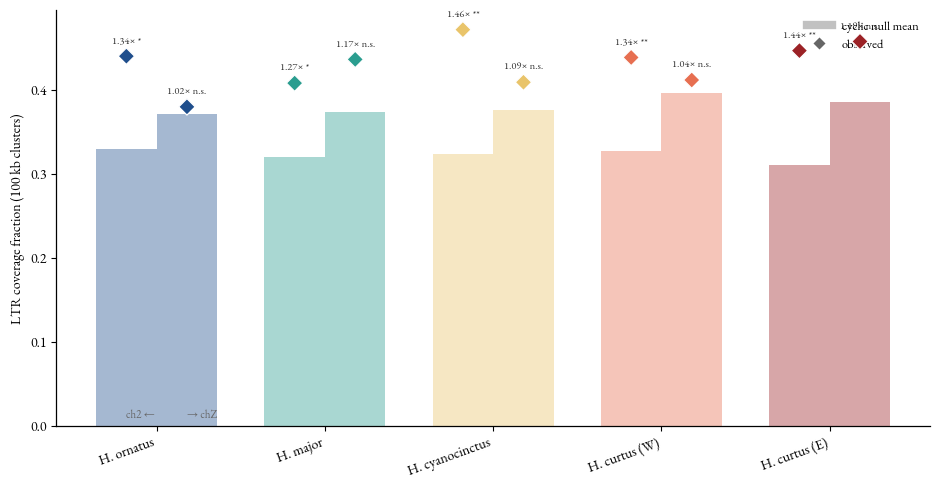

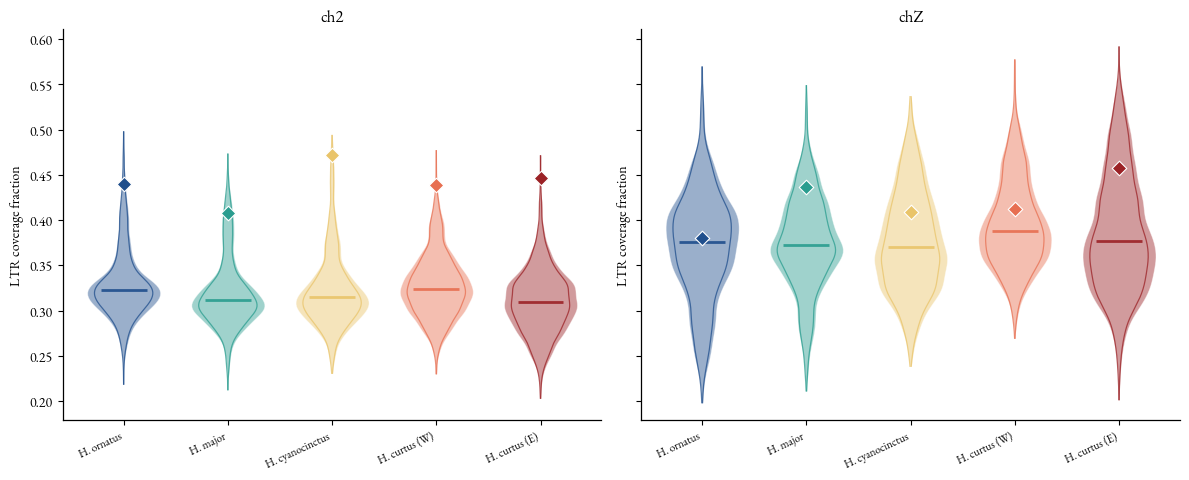


Cyclic permutation summary (Python):
species chr  n_clusters method  observed  null_mean  null_sd     fold        z  p_greater  ntimes
   horn ch2          79 python  0.440203   0.329601 0.038772 1.335564 2.852665   0.016197    5000
   horn chZ          38 python  0.379928   0.371526 0.061092 1.022616 0.137536   0.474705    5000
   hmaj ch2          77 python  0.408142   0.320230 0.040018 1.274529 2.196815   0.045391    5000
   hmaj chZ          41 python  0.436373   0.373797 0.053404 1.167405 1.171738   0.122975    5000
    hcy ch2          73 python  0.471768   0.323264 0.042155 1.459389 3.522800   0.004799    5000
    hcy chZ          33 python  0.409184   0.375565 0.056263 1.089516 0.597535   0.274145    5000
  hcurw ch2          61 python  0.438684   0.327769 0.036157 1.338392 3.067610   0.002799    5000
  hcurw chZ          53 python  0.411839   0.396016 0.049999 1.039957 0.316485   0.332533    5000
  hcure ch2          33 python  0.446795   0.310305 0.036543 1.439860 3.735034  

In [32]:
# Cyclic plots: bar (obs vs null mean) + violin of Rust null draws

meta = cyc.set_index(["species", "chr"])

fig, ax = plt.subplots(figsize=(9.5, 5.0))
x = np.arange(len(SPECIES))
width = 0.36
for j, ch in enumerate(CHROMS):
    xpos = x + (j - 0.5) * width
    nulls = [meta.loc[(sp, ch), "null_mean"] for sp in SPECIES]
    obs   = [meta.loc[(sp, ch), "observed"] for sp in SPECIES]
    folds = [meta.loc[(sp, ch), "fold"] for sp in SPECIES]
    ps    = [meta.loc[(sp, ch), "p_greater"] for sp in SPECIES]
    ax.bar(xpos, nulls, width=width, color=[SP_PAL[sp] for sp in SPECIES],
           alpha=0.40, edgecolor="none", label=None)
    ax.scatter(xpos, obs, marker="D", s=70,
               c=[SP_PAL[sp] for sp in SPECIES], edgecolor="white", lw=0.9, zorder=10)
    for xi, o, f, p in zip(xpos, obs, folds, ps):
        ax.text(xi, o + 0.012, f"{f:.2f}× {sigstar(p)}",
                ha="center", va="bottom", fontsize=7.5, color="0.2", fontweight="bold")

ax.plot([], [], color="0.4", lw=6, alpha=0.4, label="cyclic null mean")
ax.plot([], [], marker="D", color="0.4", lw=0, markeredgecolor="white",
        ms=7, label="observed")
ax.set_xticks(x)
ax.set_xticklabels([SP_LAB[sp] for sp in SPECIES], rotation=20, ha="right")
ax.set_ylabel(f"LTR coverage fraction ({MERGE_FOCUS/1000:.2f} kb clusters)")
ax.text(x[0] - width / 2, ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] else 0.02,
        "ch2 ←", fontsize=8, color="0.4")
ax.text(x[0] + width / 2, ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] else 0.02,
        "→ chZ", fontsize=8, color="0.4")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title(f"Cyclic null · merge={MERGE_FOCUS} bp · n={NTIMES_CYCLIC}")
fig.tight_layout()
fig.savefig(RESULTS / "hydrophis_cyclic_permutation_bars.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, ch in zip(axes, CHROMS):
    for xi, sp in enumerate(SPECIES):
        v = draws.loc[(draws.species == sp) & (draws.chr == ch), "value"].to_numpy()
        obs_val = float(meta.loc[(sp, ch), "observed"])
        vp = ax.violinplot([v], positions=[xi], widths=0.7, showextrema=False)
        for b in vp["bodies"]:
            b.set_facecolor(SP_PAL[sp]); b.set_alpha(0.45)
            b.set_edgecolor("white"); b.set_linewidth(0.6)
        ys = np.linspace(v.min(), v.max(), 256)
        dn = gaussian_kde(v)(ys); dn = dn / dn.max() * 0.28
        ax.plot(xi + dn, ys, color=SP_PAL[sp], lw=0.9, alpha=0.75)
        ax.plot(xi - dn, ys, color=SP_PAL[sp], lw=0.9, alpha=0.75)
        ax.hlines(np.median(v), xi - 0.22, xi + 0.22,
                  color=SP_PAL[sp], lw=2.0, alpha=0.9, zorder=6)
        ax.scatter(xi, obs_val, marker="D", s=55, color=SP_PAL[sp],
                   edgecolor="white", lw=0.8, zorder=10)
    ax.set_xticks(range(len(SPECIES)))
    ax.set_xticklabels([SP_LAB[sp] for sp in SPECIES], rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("LTR coverage fraction")
    ax.set_title(f"{ch}")
fig.suptitle(
    f"Cyclic null draws (Rust) · merge={MERGE_FOCUS} bp · n={NTIMES_CYCLIC}",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(RESULTS / "hydrophis_cyclic_permutation_violins.png", dpi=200)
plt.show()

print("\nCyclic permutation summary (Rust):")
print(cyc.to_string(index=False))


- Diamond = observed; violin = cyclic draws; bar = null mean
- Clusters merged at **39810 bp (39.81 kb)**; null from Rust cyclic_null
- Diamonds above bars = enrichment vs cyclic null


Diamonds sit above the bars because **observed LTR coverage at V2R clusters is higher than the cyclic null mean**.
- **Rectangle** = mean LTR coverage fraction under cyclic shifts (what you’d expect if V2Rs were randomly phased relative to LTR bands)
- **Diamond** = real coverage at the fixed 100 kb V2R clusters  
- Diamond above bar ⇒ **fold > 1** (enrichment). The label (`1.33× *`, etc.) is that fold and its p-value.

### What the plots say
- **Bar plot:** Across Hydrophis, **ch2** shows consistent enrichment (~1.27–1.45×; significant or near-significant). **chZ** diamonds are only slightly above the bars (~1.02–1.19×) and **not significant** —> CZ is already LTR-rich, so random phase still yields high coverage; the V2R-specific excess is weaker.
- **Violins:** Spread of the $n$ null draws. Diamond above the violin bulk = unusual under the cyclic null; inside/near the center = consistent with chance.

**Bottom line:** LTR enrichment at V2R clusters survives the conservative cyclic test mainly on **ch2**; on **chZ** the signal is weak/absent once LTR banding is preserved.